# Signal analysis based on image (38 channels merged in an RGB image)

## Import and Training

In [1]:
# %% [markdown]
# # ResNet18 + GASF Training Pipeline
# 
# **Goal:** Classify infant movement using ResNet18 on GASF-encoded time series images.
# 
# **Key Features:**
# 1. **Transfer Learning:** Uses ImageNet-pretrained ResNet18 (Frozen Backbone).
# 2. **Imbalance Handling:** Calculates `pos_weight` for BCE Loss to handle 80/20 split.
# 3. **Robust Optimization:** Saves best model based on Val Loss; Optimizes Threshold at the end.

# %%
import os
import sys
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, brier_score_loss,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

# --- 1. Configuration & Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# PATHS (Adjust if your folder structure is different)
# We assume the images were generated by the previous script in "_03_train/resnet_dataset"
current_dir_name = os.path.basename(os.path.dirname(os.path.abspath("__file__")))
BASE_DIR = os.path.abspath(f"../../_03_train/{current_dir_name}/resnet_dataset_multimodal")
IMG_DIR = os.path.join(BASE_DIR, "images")
META_CSV = os.path.join(BASE_DIR, "metadata.csv")
RESULT_DIR = os.path.join(BASE_DIR, "results_resnet_notebook")
os.makedirs(RESULT_DIR, exist_ok=True)

BATCH_SIZE = 32
NUM_EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Data Source: {META_CSV}")

# %% [markdown]
# ## 2. Data Loading & Custom Dataset

# %%
# Load Metadata
if not os.path.exists(META_CSV):
    raise FileNotFoundError(f"Metadata CSV not found at {META_CSV}. Run image generation first!")

df = pd.read_csv(META_CSV)

# Data Transforms (Standard ImageNet Normalization)
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

# %%
# --- 1. Data Transforms (CORRECTED) ---
# REMOVED RandomHorizontalFlip because it destroys GASF temporal structure
data_transforms = {
    'train': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
    'eval': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
}

class ResNetGASFDataset(Dataset):
    def __init__(self, metadata_df, img_root, transform=None):
        self.meta = metadata_df.reset_index(drop=True)
        self.img_root = img_root
        self.transform = transform
        
    def __len__(self):
        return len(self.meta)
    
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        # Image path: root/split/filename
        img_path = os.path.join(self.img_root, row['split'], row['filename'])
        
        # Load Image (RGB)
        image = Image.open(img_path).convert('RGB')
        label = float(row['label']) # Float for BCE Loss
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32), row.to_dict()

# Re-init datasets with correct transforms
train_set = ResNetGASFDataset(df[df['split'] == 'train'], IMG_DIR, data_transforms['train'])
val_set = ResNetGASFDataset(df[df['split'] == 'val'], IMG_DIR, data_transforms['eval'])
test_set = ResNetGASFDataset(df[df['split'] == 'test'], IMG_DIR, data_transforms['eval'])

dataloaders = {
    'train': DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test': DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

# --- 2. Model & Optimizer ---
def initialize_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # FREEZE BACKBONE
    for param in model.parameters():
        param.requires_grad = False
        
    # Replace Head
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.6), # High Dropout to replace Data Augmentation
        nn.Linear(num_ftrs, 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 1)
    )
    return model

model = initialize_model().to(DEVICE)

# Calculate Pos_Weight (Training is balanced ~1.0, but good to keep dynamic)
y_train = df[df['split'] == 'train']['label'].values
num_neg = len(y_train[y_train == 0])
num_pos = len(y_train[y_train == 1])
pos_weight_val = num_neg / num_pos if num_pos > 0 else 1.0
pos_weight_tensor = torch.tensor([pos_weight_val]).float().to(DEVICE)

# Loss (Standard BCE, no label smoothing arg)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Optimizer: Increased Weight Decay (0.05) to compensate for no Augmentation
optimizer = optim.AdamW(model.fc.parameters(), lr=5e-3, weight_decay=0.01)

# Scheduler: Cosine Annealing (Smooth decay to zero)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

# %% [markdown]
# ## 4. Training Loop (Cosine Strategy)

# %%
best_model_wts = copy.deepcopy(model.state_dict())
best_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

# Note: With Cosine Annealing, we typically run the FULL duration 
# to let the LR reach zero. We disable strict early stopping but 
# keep track of the best model.

print(f"🚀 Starting training for {NUM_EPOCHS} epochs (Cosine Schedule)...")

for epoch in range(NUM_EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for inputs, labels, _ in dataloaders['train']:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = train_loss / len(train_set)
    
    # --- VALIDATION ---
    # caluclate val loss and val balanced accuracy per epoch
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels, _ in dataloaders['val']:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE).unsqueeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            # for bal acc
            val_probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            val_labels_batch = labels.cpu().numpy().flatten()
    
    epoch_bal_acc = balanced_accuracy_score(val_labels_batch, (val_probs >= 0.5).astype(int))
    epoch_val_loss = val_loss / len(val_set)
    
    # Logging
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    
    # Scheduler Step (Per Epoch for Cosine)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:02d} | LR: {current_lr:.1e} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Bal Acc: {epoch_bal_acc:.4f}", end="")
    
    # Save Best Model (Based on LOSS)
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print("  <-- New Best")
    else:
        print("")

# Load best weights
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(RESULT_DIR, "best_resnet_model.pth"))
print("✅ Training Complete. Best model loaded.")

# %% [markdown]
# ## 5. Threshold Optimization (On Validation)

# %%
print("🔎 Optimizing Threshold on Validation Set...")
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for inputs, labels, _ in dataloaders['val']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        val_probs.extend(probs)
        val_labels.extend(labels.numpy())

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)

best_thr = 0.5
best_bal_acc = 0.0

# Scan thresholds
thresholds = np.linspace(0, 1, 101)
for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    bal = balanced_accuracy_score(val_labels, preds)
    if bal > best_bal_acc:
        best_bal_acc = bal
        best_thr = thr

print(f"🎯 Best Threshold found: {best_thr:.2f}")
print(f"   Validation Balanced Acc at best thr: {best_bal_acc:.4f}")


Device: cuda
Data Source: /home/phd2/Scrivania/CorsoRepo/Bambino/_03_train/resnet_on_images/resnet_dataset_multimodal/metadata.csv
🚀 Starting training for 50 epochs (Cosine Schedule)...
Epoch 01 | LR: 5.0e-03 | Train Loss: 0.6327 | Val Loss: 0.5636 | Val Bal Acc: 0.7000  <-- New Best
Epoch 02 | LR: 5.0e-03 | Train Loss: 0.5584 | Val Loss: 0.5911 | Val Bal Acc: 0.6500
Epoch 03 | LR: 5.0e-03 | Train Loss: 0.5717 | Val Loss: 0.5870 | Val Bal Acc: 0.3500
Epoch 04 | LR: 4.9e-03 | Train Loss: 0.5620 | Val Loss: 0.6296 | Val Bal Acc: 0.8500
Epoch 05 | LR: 4.9e-03 | Train Loss: 0.5615 | Val Loss: 0.5542 | Val Bal Acc: 0.4500  <-- New Best
Epoch 06 | LR: 4.8e-03 | Train Loss: 0.5436 | Val Loss: 0.5892 | Val Bal Acc: 0.9000
Epoch 07 | LR: 4.8e-03 | Train Loss: 0.5597 | Val Loss: 0.6071 | Val Bal Acc: 0.6000
Epoch 08 | LR: 4.7e-03 | Train Loss: 0.5541 | Val Loss: 0.5503 | Val Bal Acc: 0.4500  <-- New Best
Epoch 09 | LR: 4.6e-03 | Train Loss: 0.5427 | Val Loss: 0.5565 | Val Bal Acc: 0.4000
Epoch 1

## Final Evaluation

📝 Running Final Evaluation on Test Set...

--- TEST SET RESULTS ---
Balanced Accuracy: 0.5436
MCC: 0.0829
Brier Score: 0.1634

Classification Report:
              precision    recall  f1-score   support

         0.0     0.2581    0.2963    0.2759        27
         1.0     0.8208    0.7909    0.8056       110

    accuracy                         0.6934       137
   macro avg     0.5394    0.5436    0.5407       137
weighted avg     0.7099    0.6934    0.7012       137



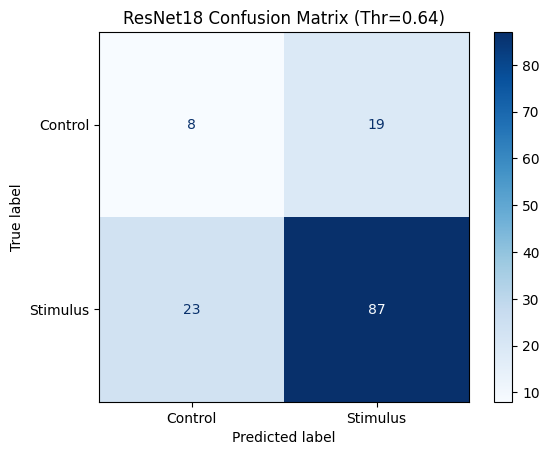

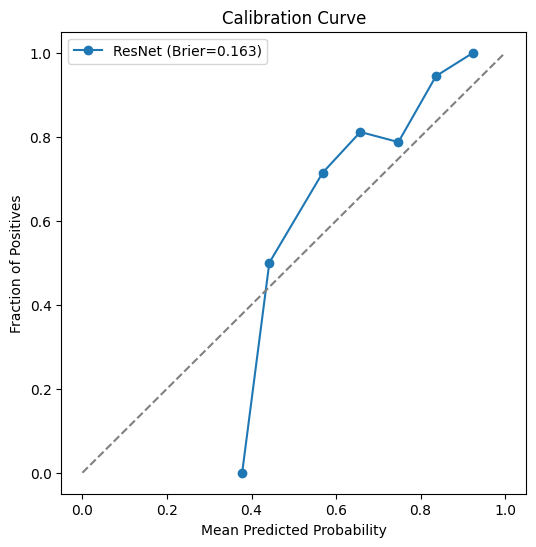


--- Per-Baby F1 Scores ---
------------------------------------------------------------
BabyID          | Age   | Sex | F1 Score
------------------------------------------------------------
bam1_044        | 6.08  | M   | 0.7333
bam1_005        | 5.42  | F   | 0.7407
bam1_020        | 4.83  | F   | 0.7742
bam1_026        | 6.54  | F   | 0.7742
bam1_008        | 6.70  | F   | 0.8000
bam1_018        | 4.96  | M   | 0.8824
bam1_024        | 6.41  | F   | 0.9091
------------------------------------------------------------


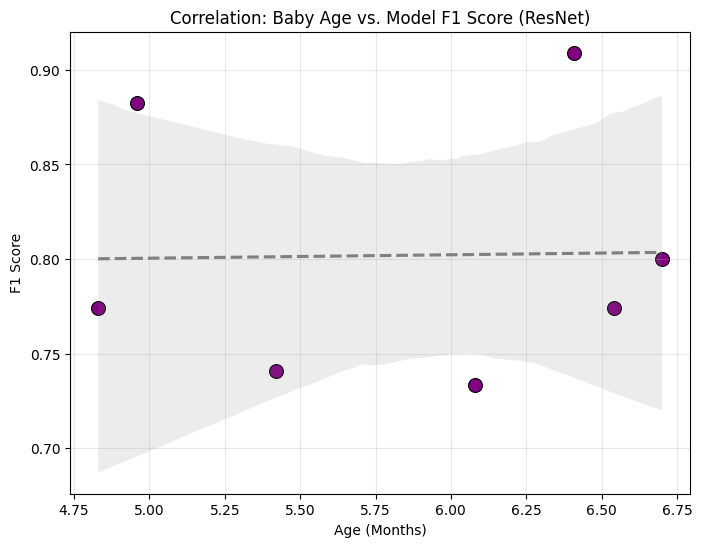

In [2]:
# ## 6. Final Evaluation (On Test)

# %%
print("📝 Running Final Evaluation on Test Set...")

test_probs = []
test_labels = []
metadata_list = [] # Store metadata for per-baby analysis

with torch.no_grad():
    for inputs, labels, meta in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        
        test_probs.extend(probs)
        test_labels.extend(labels.numpy())
        
        # Unpack metadata batch
        # DataLoader returns dict of lists, we want list of dicts
        batch_size_actual = len(labels)
        keys = meta.keys()
        for i in range(batch_size_actual):
            item = {k: meta[k][i] for k in keys}
            # Clean up tensors
            for k, v in item.items():
                if isinstance(v, torch.Tensor):
                    item[k] = v.item()
            metadata_list.append(item)

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

# Apply Optimized Threshold
y_pred_test = (test_probs >= best_thr).astype(int)

# Metrics
bal_test = balanced_accuracy_score(test_labels, y_pred_test)
mcc_test = matthews_corrcoef(test_labels, y_pred_test)
brier_test = brier_score_loss(test_labels, test_probs)

print("\n--- TEST SET RESULTS ---")
print(f"Balanced Accuracy: {bal_test:.4f}")
print(f"MCC: {mcc_test:.4f}")
print(f"Brier Score: {brier_test:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_test, digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Stimulus"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"ResNet18 Confusion Matrix (Thr={best_thr:.2f})")
plt.savefig(os.path.join(RESULT_DIR, "confusion_matrix.png"))
plt.show()

# Calibration Curve
prob_true, prob_pred = calibration_curve(test_labels, test_probs, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label=f'ResNet (Brier={brier_test:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.savefig(os.path.join(RESULT_DIR, "calibration_curve.png"))
plt.show()

# %% [markdown]
# ## 7. Per-Baby Analysis & Age Correlation

# %%
# Reconstruct DataFrame
results_df = pd.DataFrame(metadata_list)
results_df['pred_label'] = y_pred_test
results_df['true_label'] = test_labels

# Aggregate by Patient
pt_ids = results_df['pt_id'].unique()
per_baby_details = []

for pid in pt_ids:
    sub = results_df[results_df['pt_id'] == pid]
    if len(sub) < 1: continue
    
    # Calculate F1 for this baby
    # Note: If baby has mixed labels (rare here), this works. 
    # If baby is pure Control/Stimulus, F1 is 1.0 or 0.0.
    f1 = f1_score(sub['true_label'].astype(int), sub['pred_label'], zero_division=0)
    
    age = sub['age'].iloc[0]
    sex = sub['sex'].iloc[0]
    sex_str = "F" if str(sex) == "0" else "M"
    
    per_baby_details.append((pid, age, sex_str, f1))

# Sort
per_baby_details.sort(key=lambda x: x[3])

print("\n--- Per-Baby F1 Scores ---")
print("-" * 60)
print(f"{'BabyID':<15} | {'Age':<5} | {'Sex':<3} | {'F1 Score'}")
print("-" * 60)
for pid, age, sex, f1 in per_baby_details:
    print(f"{pid:<15} | {age:<5.2f} | {sex:<3} | {f1:.4f}")
print("-" * 60)

# Scatter Plot
ages = [x[1] for x in per_baby_details]
f1s = [x[3] for x in per_baby_details]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=ages, y=f1s, s=100, color='purple', edgecolor='black')
sns.regplot(x=ages, y=f1s, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title("Correlation: Baby Age vs. Model F1 Score (ResNet)")
plt.xlabel("Age (Months)")
plt.ylabel("F1 Score")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RESULT_DIR, "age_correlation.png"))
plt.show()